### Imports

In [1]:
import numpy as np
from src.preprocessing.sort_tec_data import build_sorted_dataset
from src.preprocessing.dataset import prepare_dataset
from src.configs.config import (
    BASE_DIR, OUTPUT_DIR,
    F_L1, F_L2, F_L5
)
from src.training.lstm_training import train_lstm
from src.training.transformer_training import train_transformer

from src.plots.loss_plots import (
    plot_lstm_loss, plot_transformer_loss,
)

from src.plots.prediction_plots import (
    plot_lstm_prediction, plot_transformer_prediction
)
from src.plots.delay_plots import (
    plot_diurnal_profile, 
    plot_lstm_delay,
    plot_transformer_delay
)

from src.utils.iono_delay import delay_metrics,tec_to_iono_delay
from src.utils.save_results import save_delay_csv

### 1. BASE DIRECTORY AND OUTPUT DIRECTORY

In [2]:
print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Base directory: d:\Projects\ionospheric-tec-forecasting\TEC_data
Output directory: d:\Projects\ionospheric-tec-forecasting\TEC_data\sortedDataSet


### 2. CREATING SORTED DATASET
```text
Process folders iisc1290_TECU to iisc1690_TECU and create one sorted CSV per folder containing the maximum TEC value for each minute.

Returns: Number of output CSV files written.
```

In [3]:
written_files = build_sorted_dataset()

print("TEC data sorting completed.")
print(f"Number of output CSV files written: {written_files}")
print(f"Saved sorted CSV files to: {OUTPUT_DIR}")

TEC data sorting completed.
Number of output CSV files written: 41
Saved sorted CSV files to: d:\Projects\ionospheric-tec-forecasting\TEC_data\sortedDataSet


#### QUICK SANITY CHECK

> print first 6 lines of the first output file


In [4]:
sample_file = OUTPUT_DIR / "iisc1290_TECU_sorted.csv"
if sample_file.exists():
    with sample_file.open("r", newline="", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5:
                break
else:
    print(f"Sample file not found: {sample_file}")

Time(UTC),TEC(TECU)
09-05-23 00:00,42.390972
09-05-23 00:01,51.206161
09-05-23 00:02,32.852289
09-05-23 00:03,34.870453
09-05-23 00:04,39.373245


## 3. Load & Preprocess
```text
Loads sorted CSVs into a (days × minutes) numpy matrix, 
builds supervised input/target pairs, and 
normalises using training stats only.
```

In [5]:
X_train, y_train, X_val, y_val, stats, daily_matrix, daily_files = prepare_dataset()

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"Norm stats : {stats}")


X_train : (29, 1440, 1)   y_train : (29, 1440, 1)
X_val   : (11, 1440, 1)     y_val   : (11, 1440, 1)
Norm stats : {'x_mean': 87.88667297363281, 'x_std': 45.894798288808595, 'y_mean': 86.92459106445312, 'y_std': 45.30130768822266}


## 4. TRAIN LSTM

> Dataset consists of 41 chronologically sorted TEC files.

```text
Training Set
------------
Input  : Days  1-29
Target : Days  2-30

Validation Set
--------------
Input  : Days 30-40
Target : Days 31-41

Forecast
--------
Input  : Day 40
Output : Day 41
```



In [6]:
lstm_model, lstm_history = train_lstm(X_train, y_train, X_val, y_val)

Model: "LSTM_TEC_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1440, 64)       │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1440, 32)       │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1440, 1)        │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - loss: 0.5828 - val_loss: 0.1955
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 942ms/step - loss: 0.1751 - val_loss: 0.1785
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 919ms/step - loss: 0.1546 - val_loss: 0.1267
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 942ms/step - loss: 0.1474 - val_loss: 0.1349
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 885ms/step - loss: 0.1391 - val_loss: 0.1339
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 876ms/step - loss: 0.1361 - val_loss: 0.1247
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 884ms/step - loss: 0.1337 - val_loss: 0.1236
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 901ms/step - loss: 0.1328 - val_loss: 0.1255
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 920ms/step - loss: 0.1322 - val_loss: 0.1232
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 891ms/step - loss: 0.1315 - val_loss: 0.1215
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 865ms/step - loss: 0.1309 - val_loss: 0.1220
Epoch 12/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 876ms/step - loss: 0.1306 - val_los

## 5. LSTM LOSS vs VALIDATION PLOT

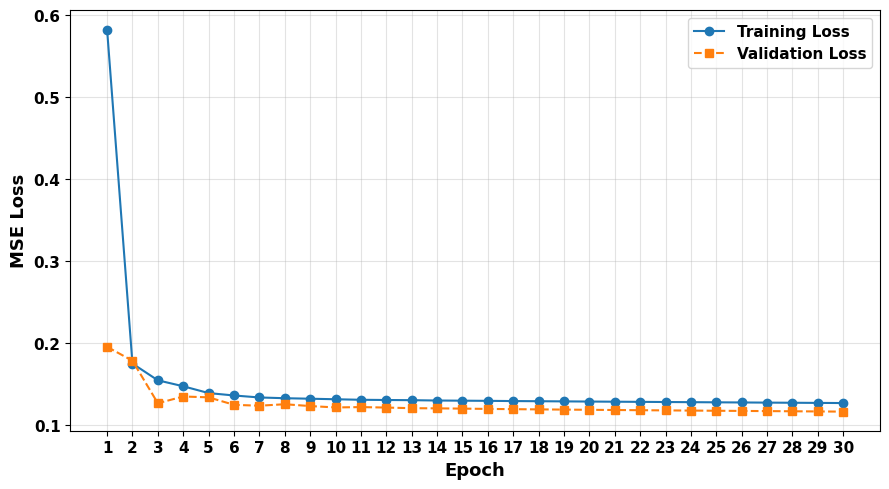

Final train loss : 0.126896
Final val   loss : 0.116433


In [7]:
plot_lstm_loss(lstm_history)

## 6. LSTM Day-41 PREDICTION

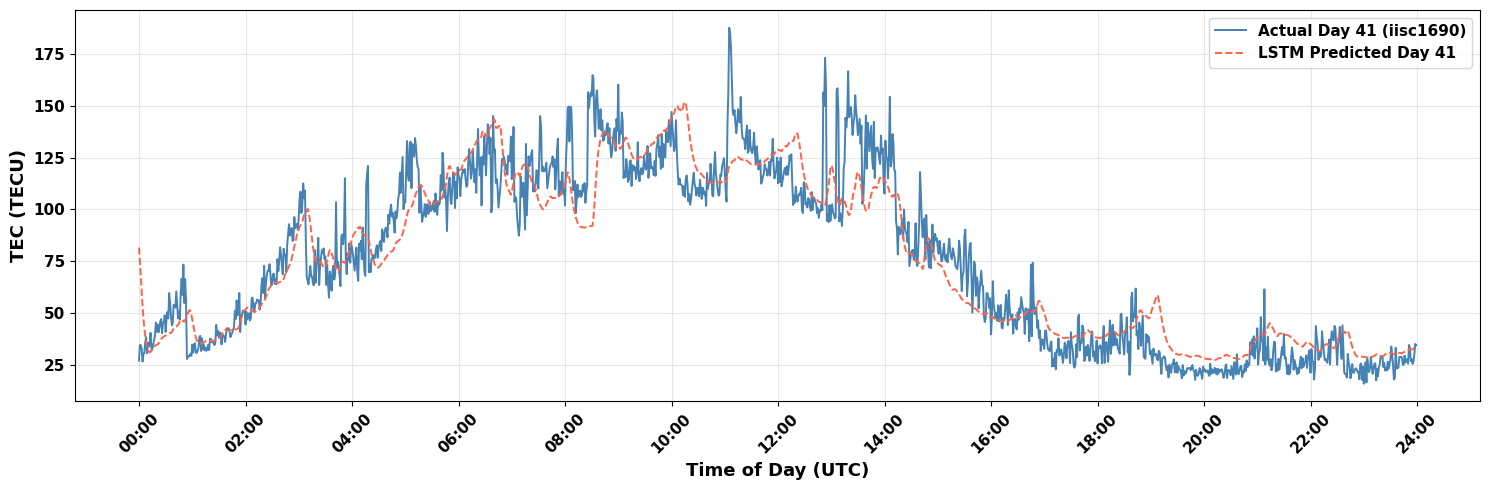

LSTM  Day-41 RMSE : 15.6157 TECU
LSTM  Day-41 MAE  : 11.4620 TECU


In [8]:
x_mean, x_std = stats["x_mean"], stats["x_std"]
y_mean, y_std = stats["y_mean"], stats["y_std"]
 
day40_raw  = daily_matrix[39]
actual41   = daily_matrix[40]
 
day40_in        = ((day40_raw - x_mean) / x_std)[np.newaxis, ..., np.newaxis]
pred41_norm     = lstm_model.predict(day40_in, verbose=0)[0, :, 0]
lstm_pred41     = pred41_norm * y_std + y_mean
 
lstm_rmse, lstm_mae = plot_lstm_prediction(actual41, lstm_pred41)


## 7. TRAIN TRANSFORMER

In [9]:
transformer_model, transformer_history = train_transformer(X_train, y_train, X_val, y_val)

Model: "CNN_Transformer_TEC"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1440, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1440, 32)  │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1440, 32)  │        512 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1440, 32)  │      1,984 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1440, 96)  │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1440, 96)  │        192 │ concatenate[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1440, 64)  │      6,208 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1440, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_attention_en… │ (None, 1440, 64)  │     49,984 │ add[0][0]         │
│ (LocalAttentionEnc… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_attention_en… │ (None, 1440, 64)  │     49,984 │ local_attention_… │
│ (LocalAttentionEnc… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1440, 1)   │         65 │ local_attention_… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,057 (426.00 KB)

 Trainable params: 109,057 (426.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - loss: 1.0652 - val_loss: 0.3831
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - loss: 0.3838 - val_loss: 0.4089
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - loss: 0.2437 - val_loss: 0.1489
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - loss: 0.1837 - val_loss: 0.2203
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - loss: 0.1644 - val_loss: 0.1366
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - loss: 0.1480 - val_loss: 0.1764
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - loss: 0.1453 - val_loss: 0.1431
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - loss: 0.1383 - val_loss: 0.1541
Epoch 9/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - loss: 0.1358 - val_loss: 0.1480
Epoch 10/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - loss: 0.1329 - val_loss: 0.1431
Epoch 11/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - loss: 0.1310 - val_loss: 0.1460
Epoch 12/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - loss: 0.1293 - val_l

## 8. TRANSFORMER LOSS vs VALIDATION PLOT

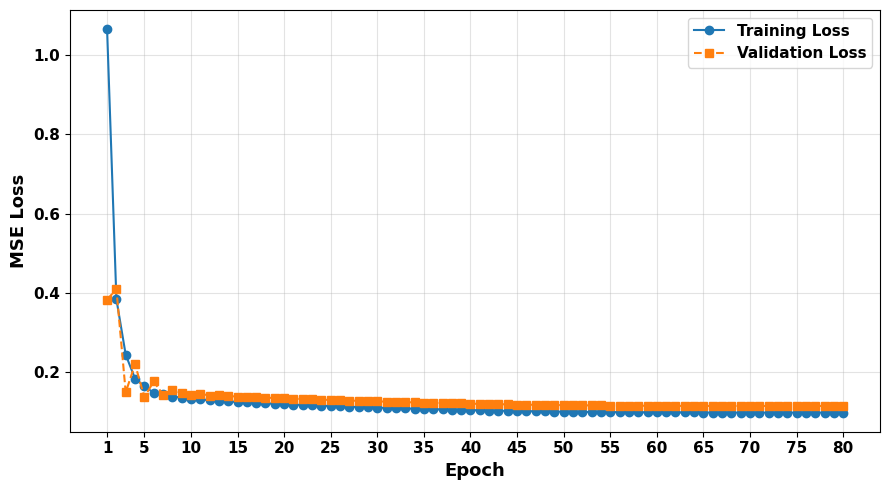

Final train loss : 0.098003
Final val   loss : 0.114632


In [10]:
plot_transformer_loss(transformer_history)

## 9. TRANSFORMER Day-41 PREDICTION

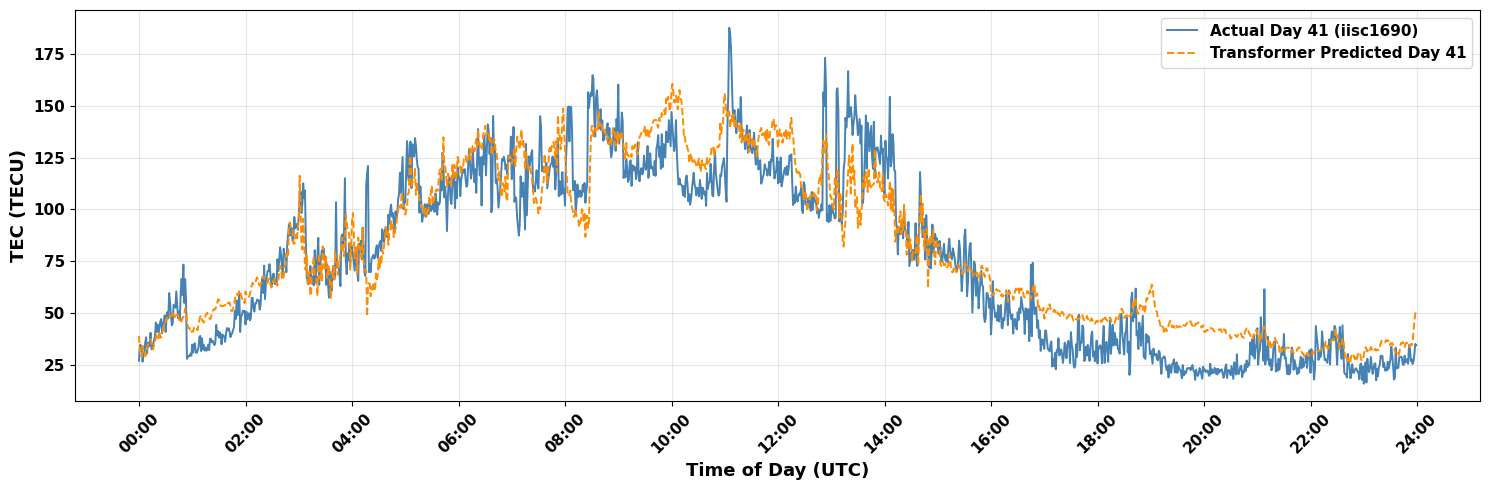

Transformer Day-41 RMSE : 15.4414 TECU
Transformer Day-41 MAE  : 12.2404 TECU


In [11]:
day40_in_t         = ((day40_raw - x_mean) / x_std)[np.newaxis, ..., np.newaxis]
trans_pred41_norm  = transformer_model.predict(day40_in_t, verbose=0)[0, :, 0]
trans_pred41       = trans_pred41_norm * y_std + y_mean
 
trans_rmse, trans_mae = plot_transformer_prediction(actual41, trans_pred41)


## 10. MODEL COMPARISON SUMMARY

In [12]:
print("=" * 45)
print(f"{'Model':<15} {'RMSE (TECU)':>12} {'MAE (TECU)':>12}")
print("-" * 45)
print(f"{'LSTM':<15} {lstm_rmse:>12.4f} {lstm_mae:>12.4f}")
print(f"{'Transformer':<15} {trans_rmse:>12.4f} {trans_mae:>12.4f}")
print("=" * 45)

Model            RMSE (TECU)   MAE (TECU)
---------------------------------------------
LSTM                 15.6157      11.4620
Transformer          15.4414      12.2404


## 11. IONOSPHERIC DELAY - LSTM PER FREQUENCY

```text
F_L1     = 1575.42e6 Hz
F_L2     = 1227.60e6 Hz
F_L5     = 1176.45e6 Hz
```

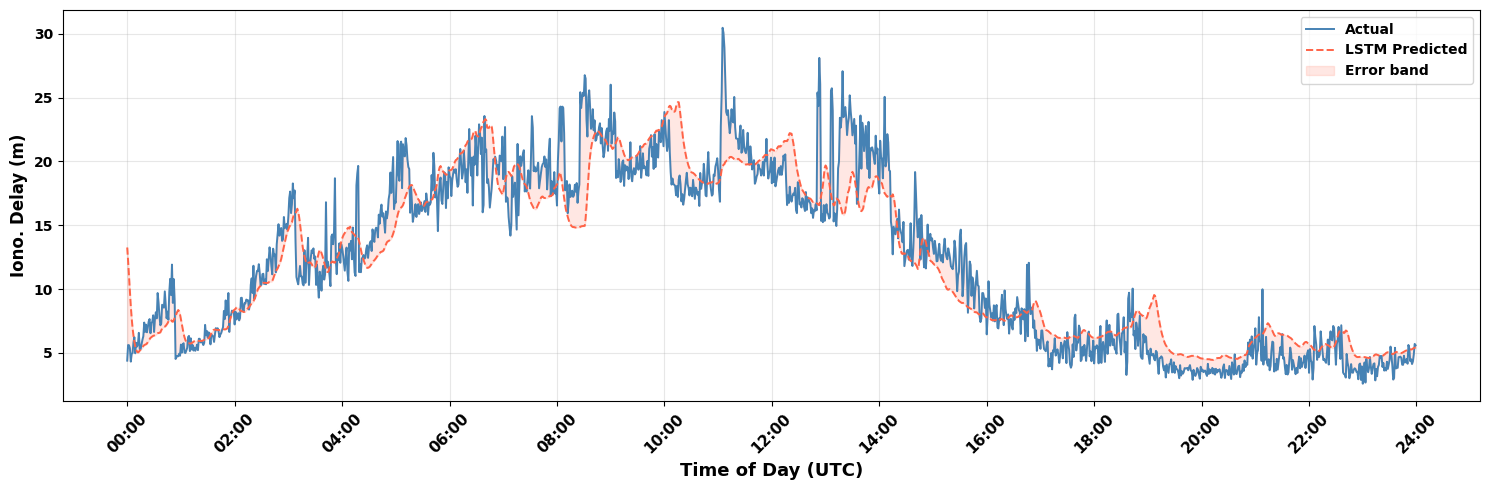

LSTM 1575420000.0 — RMSE: 2.53606 m   MAE: 1.86148 m


In [13]:
plot_lstm_delay(actual41, lstm_pred41, freq=F_L1)

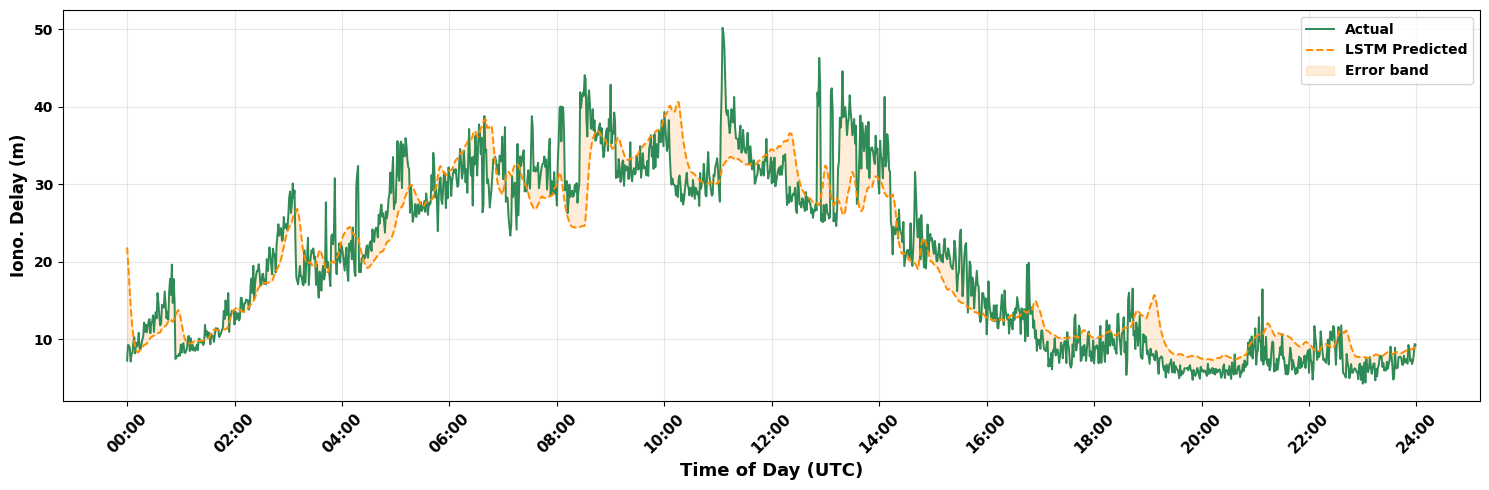

LSTM 1227600000.0 — RMSE: 4.17676 m   MAE: 3.06576 m


In [14]:
plot_lstm_delay(actual41, lstm_pred41, freq=F_L2)

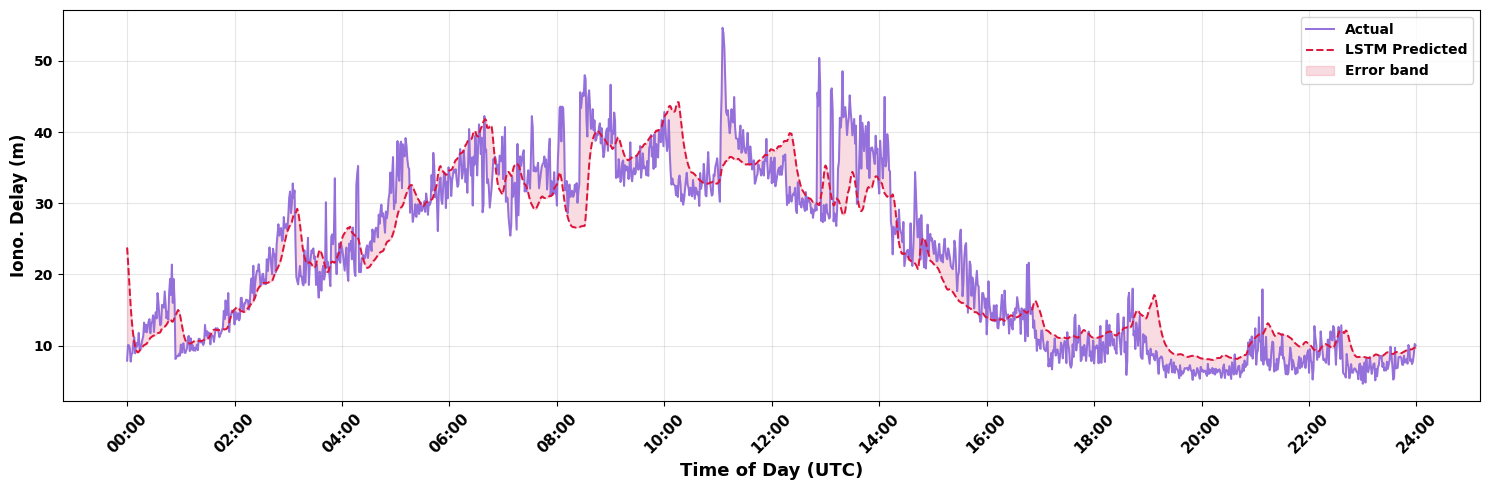

LSTM 1176450000.0 — RMSE: 4.54785 m   MAE: 3.33814 m


In [15]:
plot_lstm_delay(actual41, lstm_pred41, freq=F_L5)

## 12. IONOSPHERIC DELAY - TRANSFORMER PER FREQUENCY

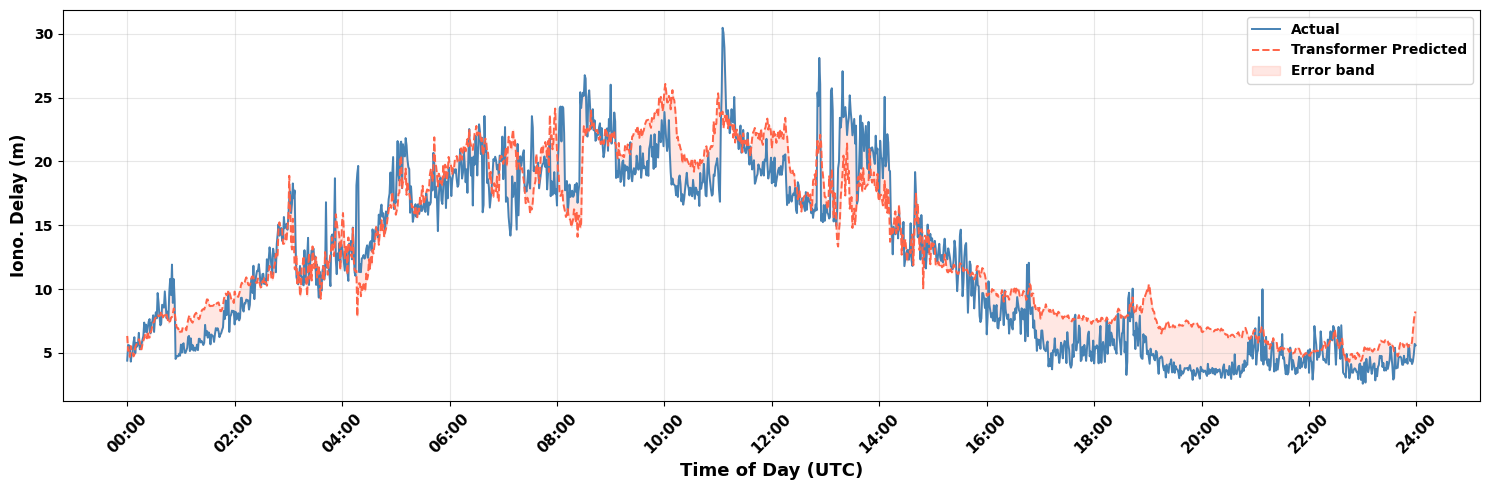

Transformer 1575420000.0 — RMSE: 2.50776 m   MAE: 1.98789 m


In [16]:
plot_transformer_delay(actual41, trans_pred41,freq=F_L1)

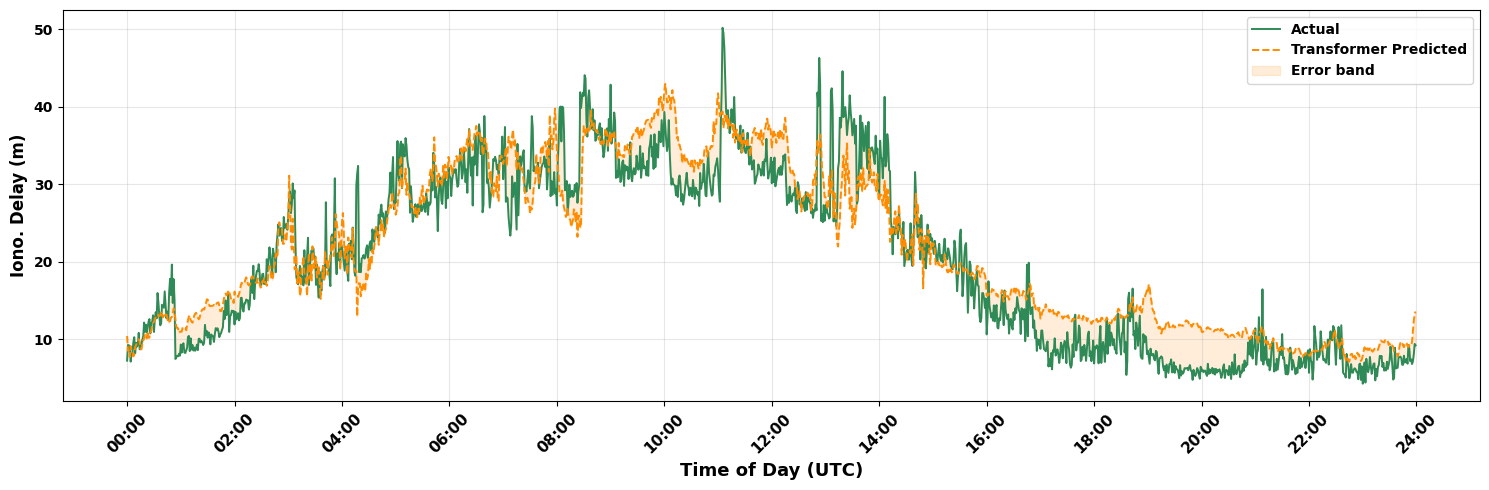

Transformer 1227600000.0 — RMSE: 4.13013 m   MAE: 3.27395 m


In [17]:
plot_transformer_delay(actual41, trans_pred41,freq=F_L2)

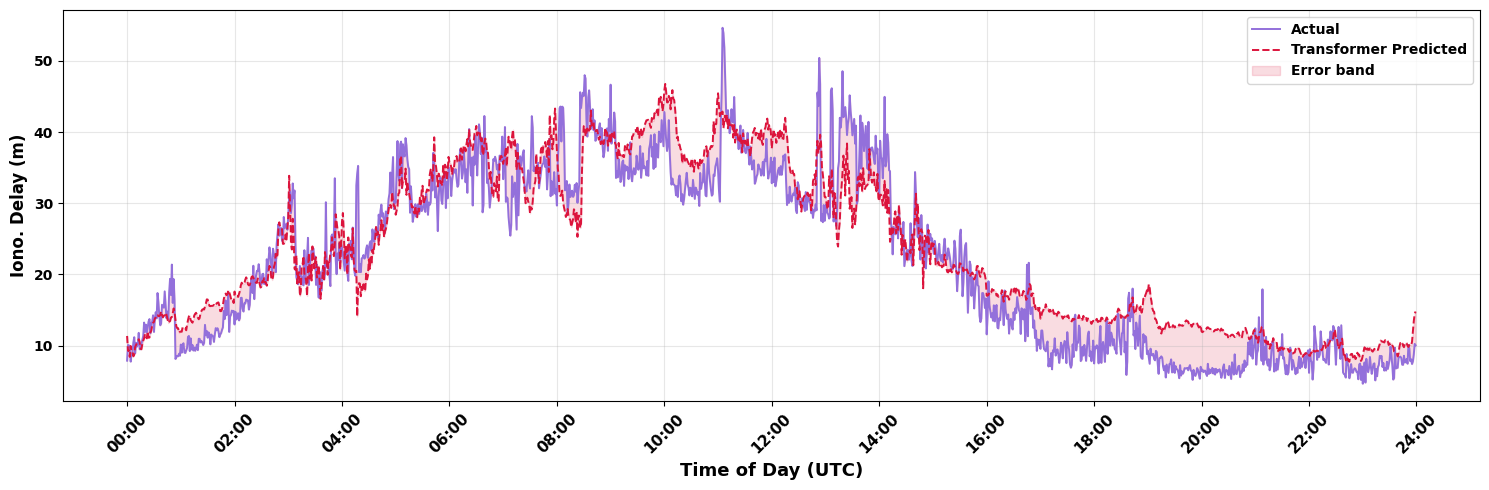

Transformer 1176450000.0 — RMSE: 4.49708 m   MAE: 3.56483 m


In [18]:
plot_transformer_delay(actual41, trans_pred41,freq=F_L5)

## 13. DIURNAL HOURLY PROFILE

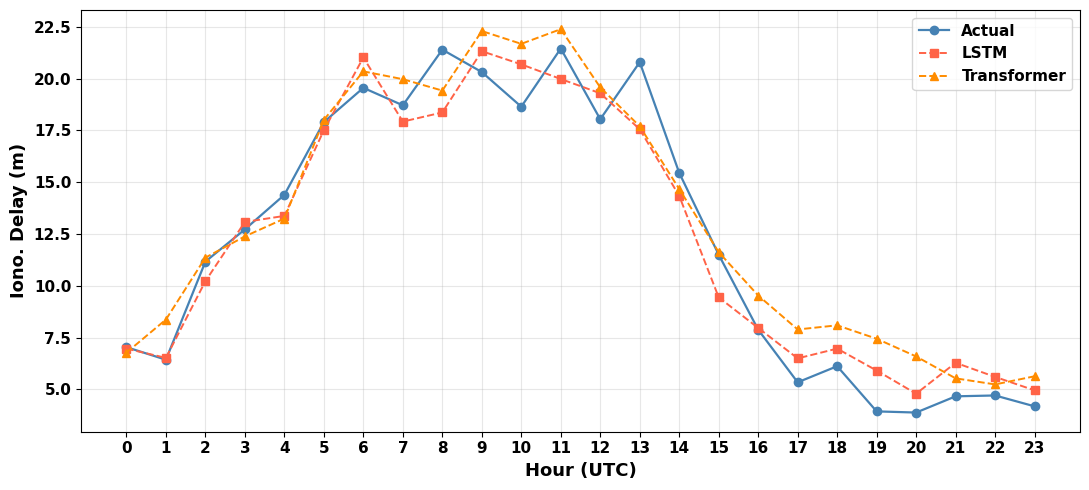

In [19]:
plot_diurnal_profile(actual41, lstm_pred41, trans_pred41, frequency=F_L1)

## 14. DELAY ERROR METRICS

In [22]:
iono_actual41 = tec_to_iono_delay(actual41)
iono_lstm41   = tec_to_iono_delay(lstm_pred41)
iono_trans41  = tec_to_iono_delay(trans_pred41)
 
print("Ionospheric Delay Error (L1, vertical) — Day 41")
print("=" * 62)
delay_metrics("LSTM",        iono_lstm41,  iono_actual41)
delay_metrics("Transformer", iono_trans41, iono_actual41)

Ionospheric Delay Error (L1, vertical) — Day 41
LSTM             RMSE = 2.53606 m   MAE = 1.86148 m   Bias = +0.01456 m
Transformer      RMSE = 2.50776 m   MAE = 1.98789 m   Bias = +0.81456 m


{'name': 'Transformer',
 'rmse': 2.507755756378174,
 'mae': 1.9878922700881958,
 'bias': 0.814563512802124}

## 15. SAVE OUTPUT CSV

In [23]:
save_delay_csv(actual41, lstm_pred41, trans_pred41)

Delay table saved → d:\Projects\ionospheric-tec-forecasting\TEC_data\sortedDataSet\iisc1690_ionospheric_delay.csv
